### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data\coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
data.shape

(12684, 26)

2. Investigate the dataset for missing or problematic data.

In [7]:
data.isnull().sum().sort_values(ascending=False)                         

car                     12576
CoffeeHouse               217
Restaurant20To50          189
CarryAway                 151
RestaurantLessThan20      130
Bar                       107
destination                 0
passanger                   0
direction_opp               0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
occupation                  0
education                   0
has_children                0
maritalStatus               0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
Y                           0
dtype: int64

In [8]:
(data.isnull().mean() * 100).sort_values(ascending=False)

car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
destination              0.000000
passanger                0.000000
direction_opp            0.000000
direction_same           0.000000
toCoupon_GEQ25min        0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ5min         0.000000
income                   0.000000
occupation               0.000000
education                0.000000
has_children             0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
time                     0.000000
temperature              0.000000
weather                  0.000000
Y                        0.000000
dtype: float64

3. Decide what to do about your missing data -- drop, replace, other...

In [9]:
data['car'].value_counts() 

car
Scooter and motorcycle                      22
Mazda5                                      22
do not drive                                22
crossover                                   21
Car that is too old to install Onstar :D    21
Name: count, dtype: int64

In [10]:
# Since car column has 99% missing values, we'll drop this column from the dataset
data_no_missing = data.drop(columns='car')

In [11]:
data_no_missing.shape

(12684, 25)

In [ ]:
# Now, let's check the unique values of other columns which have missing values

In [12]:
data_no_missing['CoffeeHouse'].value_counts() 

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64

In [13]:
data_no_missing['Restaurant20To50'].value_counts() 

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64

In [14]:
data_no_missing['CarryAway'].value_counts() 

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64

In [15]:
data_no_missing['RestaurantLessThan20'].value_counts() 

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64

In [16]:
data_no_missing['Bar'].value_counts() 

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64

In [17]:
# The other 5 columns with missing values, only a small percentage of their values are missing (<2%)
# So I have decided to fill the missing values for these columns with 'Mode' value

# List all columns that need mode imputation
cols_to_impute = ['CoffeeHouse', 'Restaurant20To50', 'CarryAway', 'RestaurantLessThan20', 'Bar']

# Loop through each and fill with mode
for col in cols_to_impute:
    data_no_missing[col] = data_no_missing[col].fillna(data_no_missing[col].mode()[0])

In [18]:
# Check to make sure there are no missing values now in the dataset 
data_no_missing.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [19]:
data_no_missing.shape

(12684, 25)

4. What proportion of the total observations chose to accept the coupon?



In [20]:
print(data_no_missing['Y'].mean() * 100)

56.84326710816777


In [ ]:
# 56.8 % of the total observations have chosen to accept the coupon

5. Use a bar plot to visualize the `coupon` column.

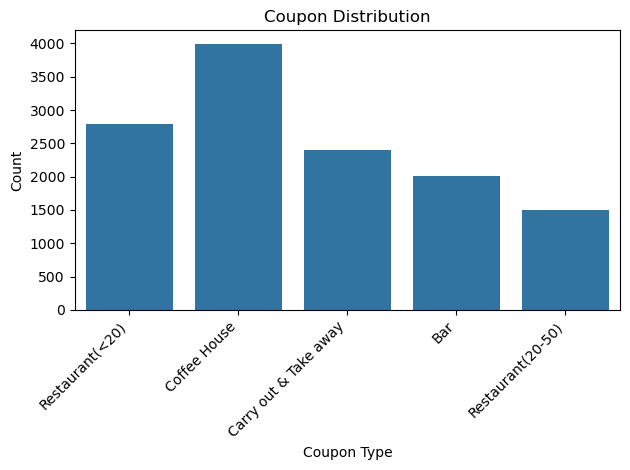

In [21]:
sns.countplot(data=data_no_missing, x='coupon')

plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

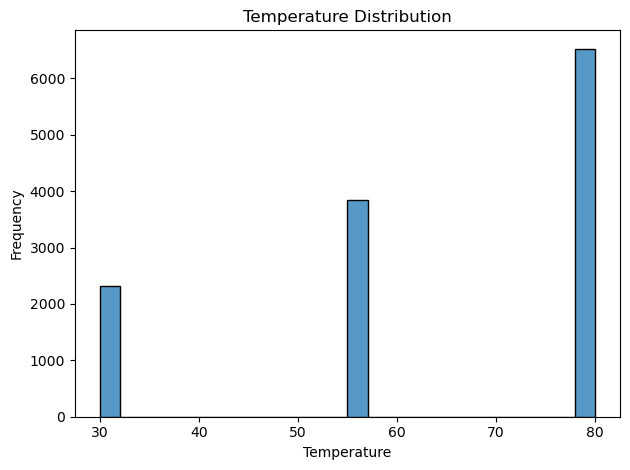

In [22]:
sns.histplot(data=data_no_missing, x='temperature')

plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [23]:
data_bar = data_no_missing.query("coupon == 'Bar'")
data_bar.head()


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


In [24]:
data_bar.shape

(2017, 25)

2. What proportion of bar coupons were accepted?


In [25]:
data_bar['Y'].mean() * 100

np.float64(41.00148735746158)

In [ ]:
# 41% of the Bar coupons were accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [43]:
bar_3orless = ['never', 'less1', '1~3']
group1 = data_bar[data_bar['Bar'].isin(bar_3orless)]['Y'].mean() * 100
group2 = data_bar[~data_bar['Bar'].isin(bar_3orless)]['Y'].mean() * 100

In [44]:
print(f"Bar 3 or fewer: {group1:.1f}%")
print(f"All others:     {group2:.1f}%")
print(f"Difference:     {group1 - group2:.1f}%")

Bar 3 or fewer: 37.1%
All others:     76.9%
Difference:     -39.8%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [44]:
print(data_bar['age'].unique())
print(data_bar['Bar'].unique())

['21' '46' '26' '31' '41' '50plus' '36' 'below21']
['never' 'less1' '1~3' 'gt8' '4~8']


In [45]:
# Define the target group: go to bar more than once a month AND age over 25
bar_often = ['1~3', '4~8', 'gt8']  # more than once a month
age_over_25 = ['26', '31', '36', '41', '46', '50plus']

group1 = data_bar[
    data_bar['Bar'].isin(bar_often) & 
    data_bar['age'].isin(age_over_25)
]['Y'].mean() * 100

# All others
group2 = data_bar[
    ~(data_bar['Bar'].isin(bar_often) & 
      data_bar['age'].isin(age_over_25))
]['Y'].mean() * 100

In [46]:
print(f"Bar > once/month AND age > 25: {group1:.1f}%")
print(f"All others:                    {group2:.1f}%")
print(f"Difference:                    {group1 - group2:.1f}%")

Bar > once/month AND age > 25: 69.0%
All others:                    33.8%
Difference:                    35.2%


In [ ]:
# Yes, those who go to bar more than once a month and are over 25 years of age, have a 69% bar coupon acceptance rate 
# compared to 33.8% for all others.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [48]:
print(data_bar['passanger'].unique())

['Friend(s)' 'Alone' 'Kid(s)' 'Partner']


In [49]:
print(data_bar['occupation'].unique())

['Architecture & Engineering' 'Student' 'Education&Training&Library'
 'Unemployed' 'Healthcare Support' 'Healthcare Practitioners & Technical'
 'Sales & Related' 'Management' 'Arts Design Entertainment Sports & Media'
 'Computer & Mathematical' 'Life Physical Social Science'
 'Personal Care & Service' 'Office & Administrative Support'
 'Construction & Extraction' 'Legal' 'Retired'
 'Community & Social Services' 'Installation Maintenance & Repair'
 'Transportation & Material Moving' 'Business & Financial'
 'Protective Service' 'Food Preparation & Serving Related'
 'Production Occupations' 'Building & Grounds Cleaning & Maintenance'
 'Farming Fishing & Forestry']


In [51]:
bar_often = ['1~3', '4~8', 'gt8']  # more than once a month
no_kid_passengers = ['Alone', 'Friend(s)', 'Partner']  # not a kid
non_farming = data_bar['occupation'] != 'Farming Fishing & Forestry'

In [52]:
# Target group
group1 = data_bar[
    data_bar['Bar'].isin(bar_often) & 
    data_bar['passanger'].isin(no_kid_passengers) &
    non_farming
]['Y'].mean() * 100

# All others
group2 = data_bar[
    ~(data_bar['Bar'].isin(bar_often) & 
      data_bar['passanger'].isin(no_kid_passengers) &
      non_farming)
]['Y'].mean() * 100

print(f"Bar > once/month, no kid, non-farming: {group1:.1f}%")
print(f"All others:                            {group2:.1f}%")
print(f"Difference:                            {group1 - group2:.1f}%")

Bar > once/month, no kid, non-farming: 70.9%
All others:                            29.8%
Difference:                            41.2%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [55]:
# Check unique values first
print(data_bar['maritalStatus'].unique())
print(data_bar['income'].unique())
print(data_bar['RestaurantLessThan20'].unique())

['Single' 'Married partner' 'Unmarried partner' 'Divorced' 'Widowed']
['$62500 - $74999' '$12500 - $24999' '$75000 - $87499' '$50000 - $62499'
 '$37500 - $49999' '$25000 - $37499' '$100000 or More' '$87500 - $99999'
 'Less than $12500']
['4~8' '1~3' 'less1' 'gt8' 'never']


In [54]:
bar_often = ['1~3', '4~8', 'gt8']
no_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
age_under_30 = ['below21', '21', '26']
cheap_restaurant_often = ['4~8', 'gt8']
low_income = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

# Group 1: bar > once, no kid passenger, not widowed
cond1 = (
    data_bar['Bar'].isin(bar_often) & 
    data_bar['passanger'].isin(no_kid_passengers) & 
    (data_bar['maritalStatus'] != 'Widowed')
)

# Group 2: bar > once and under 30
cond2 = (
    data_bar['Bar'].isin(bar_often) & 
    data_bar['age'].isin(age_under_30)
)

# Group 3: cheap restaurants > 4 times and income < 50K
cond3 = (
    data_bar['RestaurantLessThan20'].isin(cheap_restaurant_often) & 
    data_bar['income'].isin(low_income)
)

# Combined target group (OR across all three)
target_group = data_bar[cond1 | cond2 | cond3]['Y'].mean() * 100
all_others = data_bar[~(cond1 | cond2 | cond3)]['Y'].mean() * 100

print(f"Target group acceptance rate: {target_group:.1f}%")
print(f"All others acceptance rate:   {all_others:.1f}%")
print(f"Difference:                   {target_group - all_others:.1f}%")

Target group acceptance rate: 58.7%
All others acceptance rate:   30.0%
Difference:                   28.7%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
# Those who go to bar more often (i.e. more than 3 times a month) are more likely to accept bar coupons
# Those who go to bar more than once a month and are older than 25 years are more likely than others to accept bar coupons
# Those who go to bar more than once a month and have no kid passenger on the drive 
# and are not in farming, fishing or forestry occupation have a higher propensity to accept the bar coupons

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [26]:
# Type of coupons offered?
print(data_no_missing['coupon'].unique())


['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']


In [27]:
# Acceptance rate by type of coupons
data_no_missing.groupby('coupon')['Y'].mean()

coupon
Bar                      0.410015
Carry out & Take away    0.735478
Coffee House             0.499249
Restaurant(20-50)        0.441019
Restaurant(<20)          0.707107
Name: Y, dtype: float64

In [ ]:
# Acceptance rate for Restaurent(20-50) is 44%. Let's explore this further.

In [28]:
# Create a new dataframe with just Restaurent(20-50) coupon offerings
data_res2050 = data_no_missing.query("coupon == 'Restaurant(20-50)'")
data_res2050.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
14,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
18,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
36,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
40,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
58,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Single,...,4~8,1~3,1~3,never,1,1,0,0,1,0


In [42]:
data_res2050.shape

(1492, 25)

In [43]:
# Visit frequency for expensive Restaurent in a month
print(data_res2050['Restaurant20To50'].unique())

['1~3' 'less1' 'never' 'gt8' '4~8']


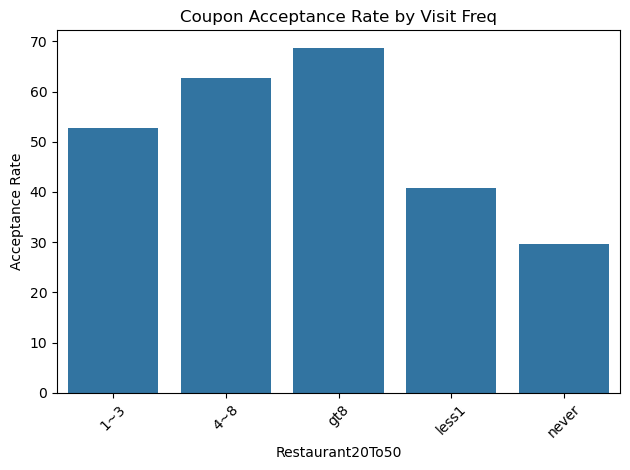

In [63]:
# Check to see the acceptance rate of Restaurent20to50 coupon by visit frequency to expense restaurents

accept_rate = data_res2050.groupby('Restaurant20To50')['Y'].mean() * 100

sns.barplot(x=accept_rate.index, y=accept_rate.values)
plt.ylabel('Acceptance Rate')
plt.xlabel('Restaurant20To50')
plt.title('Coupon Acceptance Rate by Visit Freq')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Those who visit expensive restaurents more frequently have higher acceptance rate of expensive restaurent coupons

In [45]:
# Let's look at the acceptance rate for those who visit expensive restaurents 4 or more time in a month vs. all others.
res2050_often = ['4~8', 'gt8']  # visits 4 or more times 

group1 = data_res2050[data_res2050['Restaurant20To50'].isin(res2050_often)]['Y'].mean() * 100

# All others
group2 = data_res2050[~data_res2050['Restaurant20To50'].isin(res2050_often)]['Y'].mean() * 100

In [46]:
print(f"Target group acceptance rate: {group1:.1f}%")
print(f"All others acceptance rate:   {group2:.1f}%")


Target group acceptance rate: 64.2%
All others acceptance rate:   42.3%


In [ ]:
# So we see that those who visit 4 or more times, have an aceptance rate of 64.2% while the others are at 42.3%.
# Hence, we can say those who visit the expensive restaurents more frequently, 
# have a higher propensity to accept coupons for restaurent meals of $ 20-50

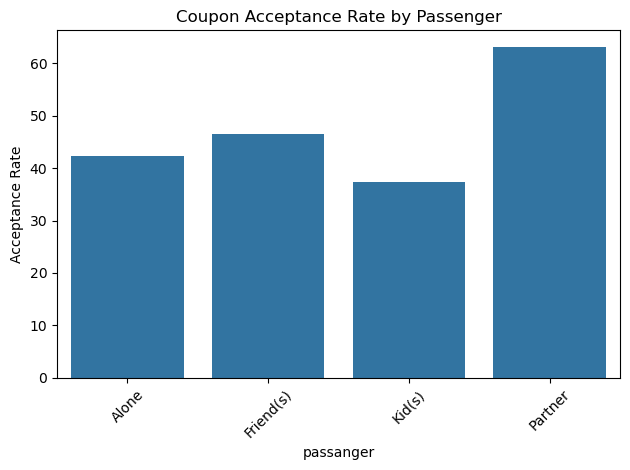

In [64]:
# Let's look at the accptance rate by type of passenger 

accept_rate = data_res2050.groupby('passanger')['Y'].mean() * 100

sns.barplot(x=accept_rate.index, y=accept_rate.values)
plt.ylabel('Acceptance Rate')
plt.xlabel('passanger')
plt.title('Coupon Acceptance Rate by Passenger')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
# Let's look at the accptance rate by when the passenger is Partner vs. all others

group1 = data_res2050[data_res2050['passanger'] == 'Partner']['Y'].mean() * 100

# All others
group2 = data_res2050[data_res2050['passanger'] != 'Partner']['Y'].mean() * 100

In [49]:
print(f"Target group acceptance rate: {group1:.1f}%")
print(f"All others acceptance rate:   {group2:.1f}%")

Target group acceptance rate: 63.1%
All others acceptance rate:   42.1%


In [ ]:
# As we can see when the passenger is the Partner, the acceptance rate for expensive rastaurent is 63.1% vs 42.1% otherwise.

In [50]:
# Let's look at the accetance rate of expensive rastaurent coupon by income level
data_res2050.groupby('income')['Y'].mean() * 100

income
$100000 or More     48.803828
$12500 - $24999     38.048780
$25000 - $37499     51.101322
$37500 - $49999     43.601896
$50000 - $62499     49.751244
$62500 - $74999     36.458333
$75000 - $87499     44.954128
$87500 - $99999     37.614679
Less than $12500    36.000000
Name: Y, dtype: float64

In [ ]:
# Although some variation is there in the accptance rate by income level, no mojor differences 

In [51]:
# Let's look at the acceptance rate by time of day of drive
data_res2050.groupby('time')['Y'].mean() * 100

time
10AM    61.607143
10PM    32.808399
2PM     53.846154
6PM     50.257732
7AM     39.860140
Name: Y, dtype: float64

In [52]:
# We'll group drives at 7AM & 10PM as they are less likely to accept coupons for expensive meals

odd_time = ['10PM', '7AM']
other_times = ['10AM', '2PM', '6PM']

group1 = data_res2050[data_res2050['time'].isin(odd_time)]['Y'].mean() * 100

# All others
group2 = data_res2050[data_res2050['time'].isin(other_times)]['Y'].mean() * 100

In [53]:
print(f"Target group acceptance rate: {group1:.1f}%")
print(f"All others acceptance rate:   {group2:.1f}%")

Target group acceptance rate: 36.5%
All others acceptance rate:   53.1%


In [ ]:
# As we expected the observations with 7AM and 10PM times have lower acceptance rate for expensive meals (36.5%) 
# vs. other times (53.1%)

In [40]:
# Acceptance rate by destination
data_res2050.groupby('destination')['Y'].mean() * 100

destination
Home               43.032159
No Urgent Place    50.243902
Work               39.860140
Name: Y, dtype: float64

In [41]:
# Acceptance rate by destination
data_res2050.groupby('occupation')['Y'].mean() * 100

occupation
Architecture & Engineering                   50.000000
Arts Design Entertainment Sports & Media     37.681159
Building & Grounds Cleaning & Maintenance    42.857143
Business & Financial                         35.897436
Community & Social Services                  38.461538
Computer & Mathematical                      52.071006
Construction & Extraction                    61.904762
Education&Training&Library                   40.566038
Farming Fishing & Forestry                   16.666667
Food Preparation & Serving Related           37.142857
Healthcare Practitioners & Technical         51.515152
Healthcare Support                           65.625000
Installation Maintenance & Repair            20.000000
Legal                                        53.846154
Life Physical Social Science                 47.368421
Management                                   45.454545
Office & Administrative Support              61.538462
Personal Care & Service                      45.454545

In [54]:
# Acceptance rate by expiration
data_res2050.groupby('expiration')['Y'].mean() * 100

expiration
1d    52.092050
2h    29.850746
Name: Y, dtype: float64

In [ ]:
# For expensive rataurent coupons, expiration time matters for acceptance. 
# One Day expiration is preferred than shorter timeframes. 

In [60]:
# Let's look at the group that visits expensive restaurents more frequently and with partner as passenger 
# with destination as No Urgent Place
# Target group
group1 = data_res2050[
    data_res2050['Restaurant20To50'].isin(res2050_often) & 
    (data_res2050['passanger'] == 'Partner') &
    (data_res2050['destination'] == 'No Urgent Place')]['Y'].mean() * 100

# # All others
group2 = data_res2050[
    ~(data_res2050['Restaurant20To50'].isin(res2050_often) & 
    (data_res2050['passanger'] == 'Partner') &
    (data_res2050['destination'] == 'No Urgent Place'))]['Y'].mean() * 100

print(f"Often visits Rest2050, partner & no urgent place: {group1:.1f}%")
print(f"All others:                            {group2:.1f}%")
print(f"Difference:                            {group1 - group2:.1f}%")



Often visits Rest2050, partner & no urgent place: 66.7%
All others:                            44.0%
Difference:                            22.7%


In [ ]:
# Those who visits expensive restaurents 4 or more times a month with partner as passenger and no urgent place as destination
# tend to accept restaurent $ 20 - 50 coupons higher rates (66.7%) compared to all others (44%).
# That is a 22.7% difference in acceptance rate.

# Based on earlier analysis, time of day and expiration times do also matter. For 7AM and 10PM drives are less likely to accept 
# coupons for expensitve restaurents. Also, recipients seem to prefer one day expiration compared to shorter durations 
# for expensive restaurent coupons.